### ベルヌーイ分布の成功確率の事後分布と事後統計量

In [2]:
import numpy as np
np.set_printoptions(precision=3)
import scipy as sp
import scipy.stats as st
import scipy.optimize as opt
import matplotlib.pyplot as plt
import japanize_matplotlib
%matplotlib inline
# import pymc
import psutil
import pandas as pd

#### 信用区間推定
##### 100(1-c)% 信用区間
+ $ Pr\{ q < a_{c} | D \} = \frac{c}{2} $
+ $ Pr\{ q > b_{c} | D \} = \frac{c}{2} $

#### HPD(Heigest Posterior Density) 区間推定
##### 100(1-c)% HPD区間
+ $ Pr\{a_{c} \leq q \leq b_{c} \} = (1 - c) $
+ $ p(a_{c}|D) = p(b_{c}|D) $

ベータ分布のHPD区間推定

In [15]:
def beta_hpdi(ci0: np.ndarray, 
              alpha: float, 
              beta: float, 
              prob: float) -> float:
    """ベータ分布のHPD区間の計算

    Args:
        ci0 (np.ndarrray): HPD区間の初期値
        alpha (float): ベータ分布のパラメータ1
        beta (float): ベータ分布のパラメータ2
        prob (float): HPD区間の確率 (0 < prob < 1)

    Returns:
        float, float: HPD区間
    """
    def hpdi_conditions(v, a, b, p) -> np.ndarray:
        """反復条件

        Args:
            v (_type_): HPD区間
            a (_type_): ベータ分布のパラメータ1
            b (_type_): ベータ分布のパラメータ2
            p (_type_): HPD区間の確率 (0 < prob < 1)

        Returns:
            np.ndarray: HPD区間の条件式の値
        """
        # 累積確率密度 CDF(b_c) - CDF(a_c) - (1-c) = 0
        eq1 = st.beta.cdf(v[1], a, b) - st.beta.cdf(v[0], a, b) - p
        # 確率密度 PDF(a_c|D) - PDF(b_c|D) = 0
        eq2 = st.beta.pdf(v[1], a, b) - st.beta.pdf(v[0], a, b)

        return np.hstack((eq1, eq2))
    
    return opt.root(hpdi_conditions, ci0, args=(alpha, beta, prob)).x

ベルヌーイ分布の成功確率の事後統計量の計算
+ $ \alpha_{new} = \sum_{i=0}^{N} p(x=0,1) + \alpha_{old} $
+ $ \beta_{new} = N - \sum_{i=0}^{N} p(x=0,1) + \beta_{old} $

In [6]:
def bernoulli_stats(data: np.ndarray,
                    a0: float,
                    b0: float,
                    prob: float):
    """ベルヌーイ分布の成功確率の事後統計量の計算

    Args:
        data (np.ndarray): データ(0 or 1)
        a0 (float): 事前分布のパラメータ1
        b0 (float): 事前分布のパラメータ2
        prob (float): 区間確率 (0 < prob < 1)

    Returns:
        tuple[pd.DataFrame, float, float]: 事後統計量のデータフレーム, 事後統計量のパラメータ1, 事後統計量のパラメータ1
    """
    n: int = data.size
    sum_data: int = data.sum()
    a = sum_data + a0
    b = n - sum_data + b0
    mean_pi = st.beta.mean(a,b)
    median_pi = st.beta.median(a,b)
    mode_pi = (a - 1.0) / (a + b - 2.0)
    sd_pi = st.beta.std(a,b)
    ci_pi = st.beta.interval(prob, a, b) # 信用区間
    hpdi_pi = beta_hpdi(
        ci_pi, # 初期値
        a, # パラメータ1
        b, # パラメータ2
        prob # 100(1-c)% HPD区間のc
    )
    stats = np.hstack((mean_pi, median_pi, mode_pi, sd_pi, ci_pi, hpdi_pi))
    stats = stats.reshape((1,8))
    stats_string = [
        '平均', '中央値', '最頻値', '標準偏差', '信用区間(下限)', '信用区間(上限)', 'HPD区間(下限)', 'HPD区間(上限)'
    ]
    param_string = ['成功確率 q']
    results = pd.DataFrame(stats, index=param_string, columns=stats_string)
    return results, a, b

ベルヌーイ分布からのデータの生成

In [5]:
p = 0.25
n = 50
np.random.seed(99)
data = st.bernoulli.rvs(p, size=n)
data

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0], dtype=int64)

ベルヌーイ分布に関する事後統計量の計算

In [9]:
a0 = 1.0
b0 = 1.0
prob = 0.95
results, a, b = bernoulli_stats(data, a0, b0, prob)
print(results.to_string(float_format='{:,.4f}'.format))

           平均    中央値    最頻値   標準偏差  信用区間(下限)  信用区間(上限)  HPD区間(下限)  HPD区間(上限)
成功確率 q 0.2885 0.2857 0.2800 0.0622    0.1749    0.4174     0.1699     0.4115


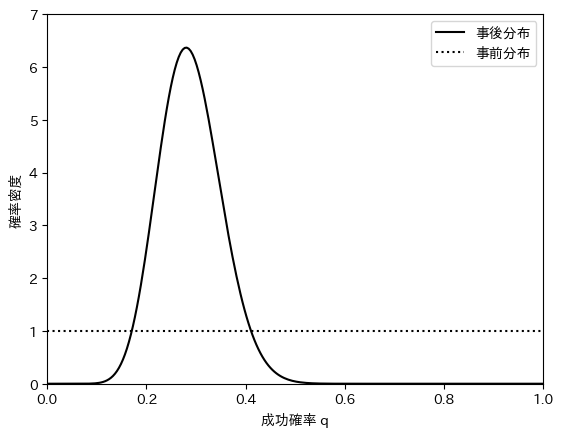

In [10]:
fig1 = plt.figure(num=1, facecolor='w')
q = np.linspace(0, 1, 250)
plt.plot(q, st.beta.pdf(q, a, b), 'k-', label='事後分布')
plt.plot(q, st.beta.pdf(q, a0, b0), 'k:', label='事前分布')
plt.xlim(0, 1)
plt.ylim(0, 7)
plt.xlabel('成功確率 q')
plt.ylabel('確率密度')
plt.legend(loc='best')
# plt.savefig('pybayes_fig_bernoulli_posterior.png', dpi=300)
plt.show()

事前分布とデータの累積が事後分布の形状に与える影響の可視化

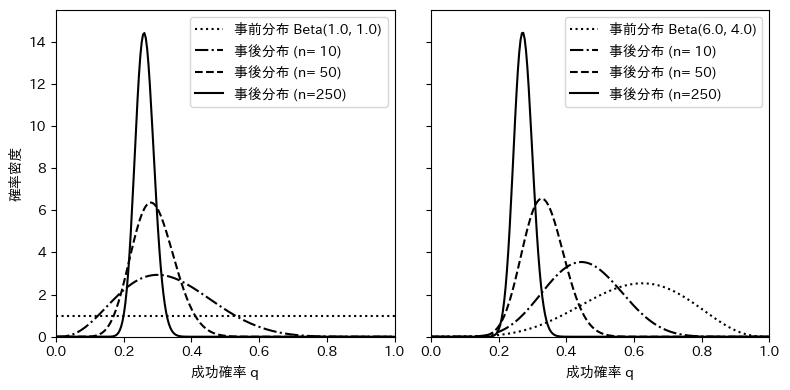

In [14]:
np.random.seed(99)
data = st.bernoulli.rvs(p, size=250)
value_size = np.array([10, 50, 250])
value_a0 = np.array([1.0, 6.0])
value_b0 = np.array([1.0, 4.0])
styles = [':', '-.', '--', '-']
fig2, ax2 = plt.subplots(1, 2, sharey='all', sharex='all', num=2, figsize=(8,4), facecolor='w')
ax2[0].set_xlim(0,1)
ax2[0].set_ylim(0,15.5)
ax2[0].set_ylabel('確率密度')
for index in range(2):
    style_index = 0

    # 事前分布
    a0_i = value_a0[index]
    b0_i = value_b0[index]
    ax2[index].plot(q, st.beta.pdf(q, a0_i, b0_i), color='k', linestyle=styles[style_index],
                    label=f'事前分布 Beta({a0_i:3.1f}, {b0_i:3.1f})')
    
    # 事後分布
    for n_j in value_size:
        style_index += 1
        sum_data = np.sum(data[:n_j])
        a_j = sum_data + a0_i
        b_j = n_j - sum_data + b0_i
        ax2[index].plot(q, st.beta.pdf(q, a_j, b_j), color='k', linestyle=styles[style_index], label=f'事後分布 (n={n_j:3d})')
        ax2[index].set_xlabel('成功確率 q')
        ax2[index].legend(loc='best')
plt.tight_layout()
# plt.savefig('pybayes_fig_bernoulli_posterior_convergence.png', dpi=300)
plt.show()

### ベイズ統計における仮説検定
#### パラメータqのとりうる値の範囲 $ S_{i}(i=0,1,2,,\cdots) $ で定義される仮説 $ H_{i} $
+ 評価方法は簡単. 事後分布の確率(事後確率)が1.0に近いか, 0.0に近いか否かで決まる
$$ H_{i} : q \in S_{i} $$

#### 事後確率
$$ Pr\{H_{i}|D\} = Pr\{ q \in S_{i} | D \} = \int_{S_{i}} p(q | D)dq $$

内閣支持率が50%以上という仮説 $ H_{0} $ の検証
$$ H_{0}: q \ge 0.5 $$
+ 上記を事後確率 $ Pr\{q \ge 0.5 | D \} = 1 - Pr\{q \lt 0.5 | D \} = 1 - \int_{0}^{0.5} p(q|D)dq $ で評価する

In [17]:
judge_prob = 1. - st.beta.cdf(0.5, a, b)
print(f"内閣支持率の仮説に対する事後確率: {judge_prob}")
print('結論: 内閣支持率50%以上はありえない')

内閣支持率の仮説に対する事後確率: 0.0008845985918934929
結論: 内閣支持率50%以上はありえない


## 事後オッズ比による仮説検定

2つの仮説候補  
$$
\begin{cases}
    H_{0}: q \in S_{0} \\
    H_{1}: q \in S_{1}
\end{cases}
$$

事後オッズ比  
$$
事後オッズ比 = \frac{Pr\{H_0|D\}}{Pr\{H_1|D\}} = \frac{Pr\{q \in S_{0} | D\}}{Pr\{q \in S_{1} | D\}}
$$

In [18]:
prob_0 = st.beta.cdf(0.5, a, b)
prob_1 = 1 - prob_0
print(prob_0)
print(prob_1)

0.9991154014081065
0.0008845985918934929


In [19]:
prob_1 / prob_0

0.0008853817993865183

事後分布は事前分布の影響を受ける.  
したがって, もし事前分布が極端にどちらかの仮説に有利な設定になっていると  
事後分布が事前分布に引きずられてしまい,  
結果としてその仮説に有利な事後オッズ比が得られる可能性がある.

### ベイズファクターによる正当な評価
+ 仮説 $ H_0 $ と $ H_1 $ を比較するベイズファクター $ B_01 $
$$ B_{01} = \frac{Pr\{H_0|D\}}{Pr\{H_1|D\}} \div \frac{Pr\{H_0\}}{Pr\{H_1\}} $$

+ 事前オッズ比
$$ 事前オッズ比 = \frac{Pr\{H_0\}}{Pr\{H_1\}} = \frac{Pr\{q \in S_0\}}{Pr\{q \in S_1\}} = \frac{\int_{S_0}p(q)dp}{\int_{S_1}p(q)dp} $$

ベイズファクターは事後オッズ比と事前オッズ比の比率

### Jeffreyesによるベイズファクターの等級

| 等級 | ベイズファクターの常用対数値 | H1にたいする支持 |
| :-- | :-- | :-- |
| 0 | $ 0 < log_{10}(B_{01}) $ | H0が支持される |
| 1 | $ -0.5 < log_{10}(B_{01}) < 0 $ | それほどでもない |
| 2 | $ -1 < log_{10}(B_{01}) < -0.5 $ | 相当なものである |
| 3 | $ -1.5 < log_{10}(B_{01}) < -1 $ | 強い |
| 4 | $ -2 < log_{10}(B_{01}) < -1.5 $ | かなり強い |
| 5 | $ log_{10}(B_{01}) < -2 | 決定的である |

2つの仮説候補
$$
\begin{cases}
    H_{0}: q \ge 0.4 \\
    H_{1}: q \lt 0.4
\end{cases}
$$
に対するベイズファクタの計算

In [20]:
posterior_odds = (1.0 - st.beta.cdf(0.4, a, b)) / st.beta.cdf(0.4, a, b)
prior_odds = (1.0 - st.uniform.cdf(0.4)) / st.uniform.cdf(0.4)
np.log10(posterior_odds / prior_odds)

-1.5175739107832402

### 両側検定に対するベイズファクタ

2つの仮説候補
$$
\begin{cases}
    H_{0}: q = q_0 \\
    H_{1}: q \ne q_0
\end{cases}
$$
に対するベイズファクタの計算は下記を使う.　　
 
spike-and-slab prior (事前分布)
$$ p(q) = p_{0}\delta(q-q_{0}) + (1 - p_{0})f(q), 0 < p_{0} < 1 $$

+ $ f(q) $ は, 区間[0,1]上の連続的な確率分布の確率密度関数
+ $ p_0 $ は, $ H_0 $ が正しい確率. つまり, $ q = q_0 $

### Aか否かの命題に対するベイズファクタSDDR(Savage-Dickey Density Ratio)
$$ B_{01} = \frac{f(q_0|D)}{q_0} $$
$$ f(q|D) = \frac{p(D|q)f(q)}{\int_{0}^{1}p(D|q)f(q)dq} $$
+ $ f(q|D) $ は, $ H_1 $ が真であるという条件の下での条件付き事後分布
+ $ f(q) $ は, $ H_1 $ が真であるという条件のもとでの条件付き事前分布
+ SDDRは, $ H_0 $ が真であるときのqの値 $ q_0 $ において, データDがもたらしたqに関する情報がどれだけ確率密度を押し上げたかを図ることで $ H_0 $ を否定するか否かを判断する基準と解釈できる

2つの仮説候補
$$
\begin{cases}
    H_{0}: q = 0.5 \\
    H_{1}: q \ne 0.5
\end{cases}
$$

In [22]:
# SDDRの常用対数値
print(np.log10(st.beta.pdf(0.5, a, b) / st.beta.pdf(0.5, a0, b0)))
print('「H0は強く否定される」という結果となった')

-1.3717982358144094
「H0は強く否定される」という結果となった


$$ p(\tilde{x}, x_1, x_2, \cdots, x_n) = p(\tilde{x}, D) $$
+ データ $ D = (x_1, x_2, \cdots, x_n) $ という同時確率分布を考えることができる

$$ p(\tilde{x}, D) = p(\tilde{x} | D) P(D) \Rightarrow p(\tilde{x} | D) = \frac{p(\tilde{x}, D)}{p(D)} $$
+ $ P(D) $ は周辺尤度と解釈できる
+ 事前分布 $ p(q) $ と 尤度 $ p(D|q) $ を使うと(qは潜在変数的な確率変数.)
$$ p(D) = \int_{0}^{1}p(D|q)p(q)dq $$
+ $ P(\tilde{x},D) $ も $ \tilde{x} $ が観測された後の周辺尤度と見なせるから
$$ p(\tilde{x}, D) = \int_{0}^{1}p(\tilde{x},D|q)p(q)dq $$
$$ p(\tilde{x}|D) = \frac{\int_{0}^{1}p(\tilde{x},D|q)p(q)dq}{\int_{0}^{1}p(D|q)p(q)dq} $$
+ これはデータDが与えられた下での $ \tilde{x} $ の条件付き確率分布であり, $ \tilde{x} $ の予測分布と呼ばれる.

+ $ \tilde{x} $ と Dが互いに独立である場合, $ p(\tilde{x},D|q) = p(\tilde{x}|q)p(D|q) $
+ $ \tilde{x} $ の予測分布 $ p(\tilde{x}|D) $ は,
$$ p(\tilde{x}|D) = \frac{\int_{0}^{1}p(\tilde{x}|q)p(D|q)p(q)dq}{\int_{0}^{1}p(D|q)p(q)dq} $$
$$ = \int_{0}^{1}p(\tilde{x}|q)\frac{p(D|q)p(q)}{\int_{0}^{1}p(D|q)p(q)dq}dq $$
$$ = \int_{0}^{1}p(\tilde{x}|q)p(q|D)dq $$
+ 予測分布は, 確率関数の期待値をqの事後分布p(q|D)で評価したものに等しい
+ パラメータが未知であるということは, 将来の $ \tilde{x} $ の分布も未知ということになる
+ 未知であるqについて平均することで予測のための分布を導出している
+ ベイズ統計学では, 「分布やモデルがわからないときは事後分布で平均すればよい」と覚える

In [24]:
# x_tilde=1となる予測分布(ベータ分布)
a / (a + b) # 成功確率

0.28846153846153844

## 損失関数とHPD区間

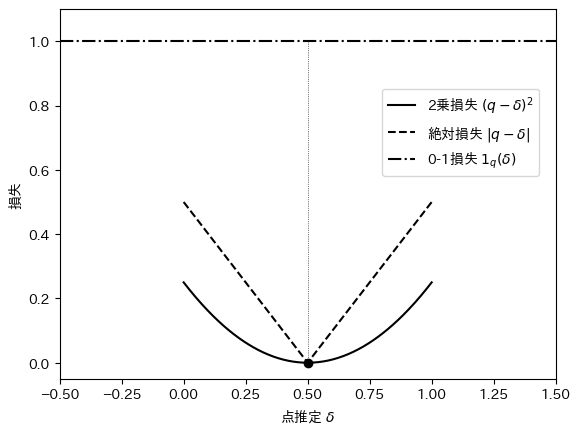

In [34]:
q = np.linspace(0, 1, 250)
fig1 = plt.figure(num=1, facecolor='w')
plt.plot(q, (q - 0.5) ** 2, 'k-', label='2乗損失 $(q-\\delta)^2$')
plt.plot(q, np.abs(q - 0.5), 'k--', label='絶対損失 $|q-\\delta|$')
plt.axhline(y=1, color='k', linestyle='-.', label='0-1損失 $1_{q}(\\delta)$')
plt.plot([0.5, 0.5], [0, 1], 'k:', linewidth=0.5)
plt.plot(0.5, 0, marker='o', mec='k', mfc='k')
plt.xlim(-.5, 1.5)
plt.ylim(-0.05, 1.1)
plt.xlabel('点推定 $\\delta$')
plt.ylabel('損失')
plt.legend(loc=(0.65, 0.55))
# plt.savefig('pybayes_fig_loss_function.png', dpi=300)
plt.show()

## 信用区間とHPD区間の比較

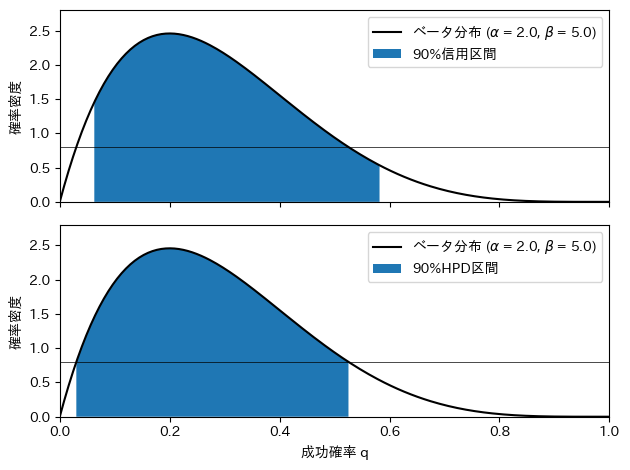

In [37]:
a = 2.0
b = 5.0
prob = 0.9
ci = st.beta.interval(prob, a, b)
hpdi = beta_hpdi(ci, a, b, prob)
q = np.linspace(0, 1, 250)
qq = [np.linspace(ci[0], ci[1], 250), np.linspace(hpdi[0], hpdi[1], 250)]
label1 = 'ベータ分布 ($\\alpha$ = {0:<3.1f}, $\\beta$ = {1:<3.1f})'.format(a,b)
label2 = ['信用区間', 'HPD区間']
fig2, ax2 = plt.subplots(2, 1, sharex='all', sharey='all', num=2, facecolor='w')
ax2[1].set_xlim(0, 1)
ax2[1].set_ylim(0, 2.8)
ax2[1].set_xlabel('成功確率 q')
for index in range(2):
    plot_label = f"{100*prob:2.0f}%{label2[index]:s}"
    ax2[index].plot(q, st.beta.pdf(q, a, b), 'k-', label=label1)
    ax2[index].fill_between(qq[index], st.beta.pdf(qq[index], a, b), linestyle='-.', label=plot_label)
    ax2[index].axhline(y=st.beta.pdf(hpdi[0], a, b), color='k', linestyle='-', linewidth=0.5)
    ax2[index].set_ylabel('確率密度')
    ax2[index].legend(loc='upper right')
plt.tight_layout()
# plt.savefig('pybayes_fig_ci_hpdi.png', dpi=300)
plt.show()